# Proyecto Final — Módulo 2
## Predicción del equipo ganador en partidas profesionales de Dota 2
### Versión pandas + scikit-learn

**Autor:** Fuentes Saldaña Juan · Grupo G38
**Dataset:** [Dota 2 Matches (Pro Leagues)](https://www.kaggle.com/datasets/darianogina/dota-2-matches-pro-leagues)

Este notebook contiene el flujo completo: carga de datos, limpieza, ingeniería de variables,
análisis exploratorio, procesamiento, entrenamiento de 3 modelos de clasificación y evaluación.

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
NAVY, GOLD = '#12395B', '#C9A227'
np.random.seed(42)

## 2. Descarga del dataset

Se utiliza `kagglehub` para descargar el dataset directamente desde Kaggle. Si no cuentas con tus
credenciales de Kaggle configuradas (`~/.kaggle/kaggle.json` o variables de entorno
`KAGGLE_USERNAME` / `KAGGLE_KEY`), la descarga fallará; en ese caso el notebook usa como respaldo
una copia local en `./data/dota2_matches.parquet` (por ejemplo, si ya descargaste y descomprimiste
el .zip de Kaggle manualmente).

In [2]:
import glob, os

DATA_PATH = None
try:
    import kagglehub
    path = kagglehub.dataset_download("darianogina/dota-2-matches-pro-leagues")
    print("Path to dataset files:", path)
    parquet_files = glob.glob(os.path.join(path, "*.parquet"))
    if parquet_files:
        DATA_PATH = parquet_files[0]
except Exception as e:
    print("No se pudo descargar con kagglehub:", e)

if DATA_PATH is None:
    fallback = "./data/dota2_matches.parquet"
    if os.path.exists(fallback):
        print("Usando copia local de respaldo:", fallback)
        DATA_PATH = fallback
    else:
        raise FileNotFoundError(
            "No se encontró el dataset. Configura tus credenciales de Kaggle o coloca "
            "dota2_matches.parquet en ./data/"
        )

print("Archivo de datos a usar:", DATA_PATH)

No se pudo descargar con kagglehub: No module named 'kagglehub'
Usando copia local de respaldo: ./data/dota2_matches.parquet
Archivo de datos a usar: ./data/dota2_matches.parquet


## 3. Carga y limpieza de datos

In [3]:
df = pd.read_parquet(DATA_PATH)
print("Shape original:", df.shape)

df = df.drop_duplicates(subset='match_id')
df = df.dropna(subset=['winner_id', 'radiant_team_id', 'dire_team_id', 'match_duration_seconds'])
df = df[df['match_duration_seconds'] >= 300]  # descarta partidas < 5 min (remakes/abandonos)
print("Shape tras limpieza:", df.shape)

df['radiant_win'] = (df['winner_id'] == df['radiant_team_id']).astype(int)
df['radiant_win'].value_counts(normalize=True)

Shape original: (193773, 130)
Shape tras limpieza: (191736, 130)


radiant_win
1    0.5121
0    0.4879
Name: proportion, dtype: float64

## 4. Ingeniería de variables

Construimos variables agregadas por equipo y, a partir de ellas, variables **diferenciales** (Radiant − Dire).

In [4]:
rad_k = [f'radiant_player_{i}_kills' for i in range(1,6)]
rad_d = [f'radiant_player_{i}_deaths' for i in range(1,6)]
rad_a = [f'radiant_player_{i}_assists' for i in range(1,6)]
rad_n = [f'radiant_player_{i}_networth' for i in range(1,6)]
dire_k = [f'dire_player_{i}_kills' for i in range(1,6)]
dire_d = [f'dire_player_{i}_deaths' for i in range(1,6)]
dire_a = [f'dire_player_{i}_assists' for i in range(1,6)]
dire_n = [f'dire_player_{i}_networth' for i in range(1,6)]

df['radiant_kills_total'] = df[rad_k].sum(axis=1)
df['dire_kills_total'] = df[dire_k].sum(axis=1)
df['radiant_deaths_total'] = df[rad_d].sum(axis=1)
df['dire_deaths_total'] = df[dire_d].sum(axis=1)
df['radiant_assists_total'] = df[rad_a].sum(axis=1)
df['dire_assists_total'] = df[dire_a].sum(axis=1)
df['radiant_networth_total'] = df[rad_n].sum(axis=1)
df['dire_networth_total'] = df[dire_n].sum(axis=1)

df['kills_diff'] = df['radiant_kills_total'] - df['dire_kills_total']
df['deaths_diff'] = df['radiant_deaths_total'] - df['dire_deaths_total']
df['assists_diff'] = df['radiant_assists_total'] - df['dire_assists_total']
df['networth_diff'] = df['radiant_networth_total'] - df['dire_networth_total']
df['networth_ratio'] = df['radiant_networth_total'] / df['dire_networth_total'].replace(0, np.nan)
df['kda_radiant'] = (df['radiant_kills_total'] + df['radiant_assists_total']) / df['radiant_deaths_total'].replace(0, 1)
df['kda_dire'] = (df['dire_kills_total'] + df['dire_assists_total']) / df['dire_deaths_total'].replace(0, 1)
df['kda_diff'] = df['kda_radiant'] - df['kda_dire']

numeric_features = ['match_duration_seconds', 'first_blood_time_seconds',
                     'kills_diff', 'assists_diff', 'networth_diff', 'networth_ratio', 'kda_diff']
categorical_features = ['league_tier', 'league_region', 'series_type']
target = 'radiant_win'

data = df[numeric_features + ['deaths_diff'] + categorical_features + [target]].dropna()
print("Dataset de modelado:", data.shape)
data.describe().T

Dataset de modelado: (102743, 12)


,count,mean,std,min,25%,50%,75%,max
match_duration_seconds,102743.0,2017.053103,587.945002,301.0,1619.0,1942.0,2333.0,8199.0
first_blood_time_seconds,102743.0,115.219412,142.820291,-83.0,18.0,104.0,171.0,3482.0
kills_diff,102743.0,0.22093,18.414721,-71.0,-15.0,0.0,16.0,67.0
assists_diff,102743.0,0.202729,41.552008,-143.0,-35.0,1.0,35.0,138.0
networth_diff,102743.0,-286.762067,23991.582438,-135201.0,-21523.5,2239.0,20756.0,126666.0
networth_ratio,102743.0,1.080984,0.421347,0.150496,0.716049,1.029733,1.394499,4.913604
kda_diff,102743.0,0.268807,8.186096,-176.0,-3.757942,0.064327,3.982599,170.944444
deaths_diff,102743.0,-0.23187,18.325688,-65.0,-15.0,0.0,15.0,69.0
radiant_win,102743.0,0.507558,0.499945,0.0,0.0,1.0,1.0,1.0


## 5. Análisis exploratorio de datos (EDA)

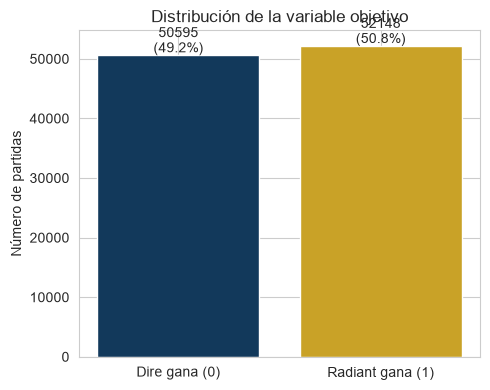

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = data[target].value_counts().sort_index()
ax.bar(['Dire gana (0)', 'Radiant gana (1)'], counts.values, color=[NAVY, GOLD])
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"{v}\n({v/len(data)*100:.1f}%)", ha='center')
ax.set_ylabel('Número de partidas')
ax.set_title('Distribución de la variable objetivo')
plt.tight_layout(); plt.show()

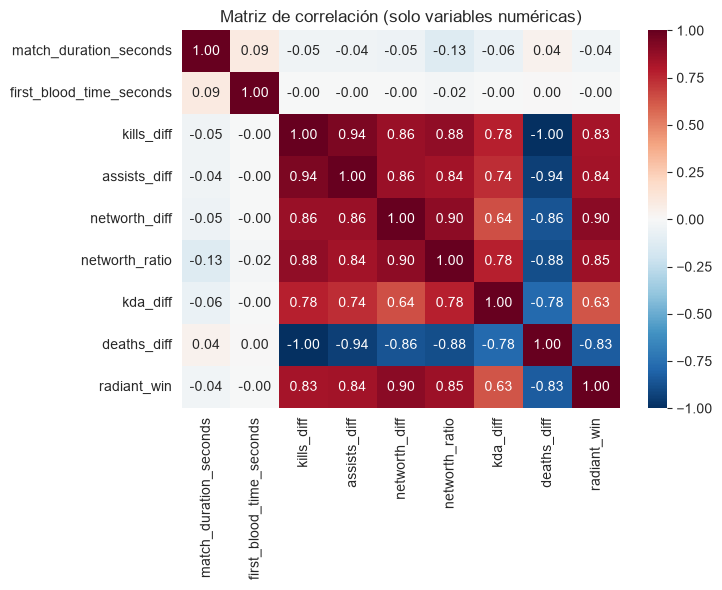


Correlación con radiant_win:
radiant_win                 1.000000
networth_diff               0.904890
networth_ratio              0.852760
assists_diff                0.840421
kills_diff                  0.829748
kda_diff                    0.632174
first_blood_time_seconds   -0.002530
match_duration_seconds     -0.038062
deaths_diff                -0.830303
Name: radiant_win, dtype: float64

>> deaths_diff tiene r = -1.00 con kills_diff (colinealidad perfecta) -> se elimina del modelado.


In [6]:
corr_cols = numeric_features + ['deaths_diff', target]
corr = data[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de correlación (solo variables numéricas)')
plt.tight_layout(); plt.show()

print("\nCorrelación con radiant_win:")
print(corr[target].sort_values(ascending=False))
print("\n>> deaths_diff tiene r = -1.00 con kills_diff (colinealidad perfecta) -> se elimina del modelado.")

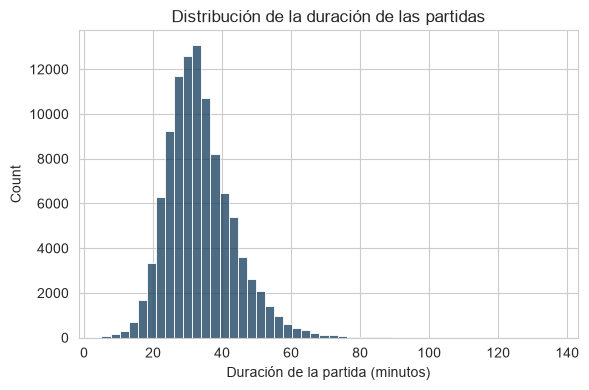

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data['match_duration_seconds']/60, bins=50, color=NAVY, ax=ax)
ax.set_xlabel('Duración de la partida (minutos)')
ax.set_title('Distribución de la duración de las partidas')
plt.tight_layout(); plt.show()

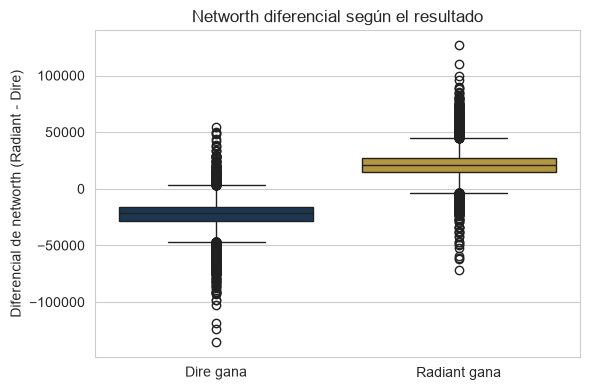

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=data, x=target, y='networth_diff', hue=target, palette=[NAVY, GOLD], legend=False, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Dire gana', 'Radiant gana'])
ax.set_xlabel(''); ax.set_ylabel('Diferencial de networth (Radiant - Dire)')
ax.set_title('Networth diferencial según el resultado')
plt.tight_layout(); plt.show()

## 6. Procesamiento de datos

Partición train/test, escalamiento y codificación de variables categóricas.

In [9]:
# Muestra estratificada por eficiencia de cómputo
SAMPLE_SIZE = 30000
data_s, _ = train_test_split(data, train_size=SAMPLE_SIZE, stratify=data[target], random_state=42)

X = data_s[numeric_features + categorical_features]  # deaths_diff excluida por colinealidad
y = data_s[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

Train: (24000, 10) Test: (6000, 10)


## 7. Modelado: 3 clasificadores con búsqueda de hiperparámetros

In [10]:
results = []
best_estimators = {}

def evaluate(name, pipe, best_params, fit_time):
    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)
    y_proba_test = pipe.predict_proba(X_test)[:, 1]
    row = {
        'modelo': name, 'mejores_hiperparametros': json.dumps(best_params),
        'accuracy_train': accuracy_score(y_train, y_pred_train),
        'accuracy_test': accuracy_score(y_test, y_pred_test),
        'precision_test': precision_score(y_test, y_pred_test),
        'recall_test': recall_score(y_test, y_pred_test),
        'f1_test': f1_score(y_test, y_pred_test),
        'roc_auc_test': roc_auc_score(y_test, y_proba_test),
        'tiempo_ajuste_s': fit_time,
    }
    results.append(row)
    print(row)
    return row

In [11]:
import time

# 1) Regresión Logística
t0 = time.time()
pipe_lr = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
gs_lr = GridSearchCV(pipe_lr, {'clf__C': [0.01, 0.1, 1, 10]}, cv=3, scoring='roc_auc', n_jobs=1)
gs_lr.fit(X_train, y_train)
best_estimators['Regresión Logística'] = gs_lr.best_estimator_
evaluate('Regresión Logística', gs_lr.best_estimator_, gs_lr.best_params_, time.time() - t0)

{'modelo': 'Regresión Logística', 'mejores_hiperparametros': '{"clf__C": 10}', 'accuracy_train': 0.98975, 'accuracy_test': 0.9878333333333333, 'precision_test': 0.9878529218647406, 'recall_test': 0.9881773399014778, 'f1_test': 0.9880151042521753, 'roc_auc_test': 0.9981481388868052, 'tiempo_ajuste_s': 0.5253052711486816}


{'modelo': 'Regresión Logística',
 'mejores_hiperparametros': '{"clf__C": 10}',
 'accuracy_train': 0.98975,
 'accuracy_test': 0.9878333333333333,
 'precision_test': 0.9878529218647406,
 'recall_test': 0.9881773399014778,
 'f1_test': 0.9880151042521753,
 'roc_auc_test': 0.9981481388868052,
 'tiempo_ajuste_s': 0.5253052711486816}

In [12]:
# 2) Random Forest
t0 = time.time()
pipe_rf = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42))])
gs_rf = GridSearchCV(pipe_rf, {'clf__n_estimators': [150, 300], 'clf__max_depth': [6, 10, None]},
                      cv=3, scoring='roc_auc', n_jobs=1)
gs_rf.fit(X_train, y_train)
best_estimators['Random Forest'] = gs_rf.best_estimator_
evaluate('Random Forest', gs_rf.best_estimator_, gs_rf.best_params_, time.time() - t0)

{'modelo': 'Random Forest', 'mejores_hiperparametros': '{"clf__max_depth": 10, "clf__n_estimators": 300}', 'accuracy_train': 0.9940833333333333, 'accuracy_test': 0.9878333333333333, 'precision_test': 0.9904290429042905, 'recall_test': 0.9855500821018063, 'f1_test': 0.9879835390946502, 'roc_auc_test': 0.998871412734532, 'tiempo_ajuste_s': 32.4463369846344}


{'modelo': 'Random Forest',
 'mejores_hiperparametros': '{"clf__max_depth": 10, "clf__n_estimators": 300}',
 'accuracy_train': 0.9940833333333333,
 'accuracy_test': 0.9878333333333333,
 'precision_test': 0.9904290429042905,
 'recall_test': 0.9855500821018063,
 'f1_test': 0.9879835390946502,
 'roc_auc_test': 0.998871412734532,
 'tiempo_ajuste_s': 32.4463369846344}

In [13]:
# 3) Gradient Boosting
t0 = time.time()
pipe_gb = Pipeline([('prep', preprocessor), ('clf', HistGradientBoostingClassifier(random_state=42))])
gs_gb = GridSearchCV(pipe_gb, {'clf__max_iter': [100, 200], 'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [3, 6]},
                      cv=3, scoring='roc_auc', n_jobs=1)
gs_gb.fit(X_train, y_train)
best_estimators['Gradient Boosting'] = gs_gb.best_estimator_
evaluate('Gradient Boosting', gs_gb.best_estimator_, gs_gb.best_params_, time.time() - t0)

{'modelo': 'Gradient Boosting', 'mejores_hiperparametros': '{"clf__learning_rate": 0.05, "clf__max_depth": 3, "clf__max_iter": 200}', 'accuracy_train': 0.9902916666666667, 'accuracy_test': 0.9881666666666666, 'precision_test': 0.9888231426692965, 'recall_test': 0.9878489326765189, 'f1_test': 0.9883357976014457, 'roc_auc_test': 0.9989229798926982, 'tiempo_ajuste_s': 10.41421127319336}


{'modelo': 'Gradient Boosting',
 'mejores_hiperparametros': '{"clf__learning_rate": 0.05, "clf__max_depth": 3, "clf__max_iter": 200}',
 'accuracy_train': 0.9902916666666667,
 'accuracy_test': 0.9881666666666666,
 'precision_test': 0.9888231426692965,
 'recall_test': 0.9878489326765189,
 'f1_test': 0.9883357976014457,
 'roc_auc_test': 0.9989229798926982,
 'tiempo_ajuste_s': 10.41421127319336}

## 8. Comparación de resultados y selección del mejor modelo

In [14]:
results_df = pd.DataFrame(results)
results_df

,modelo,mejores_hiperparametros,accuracy_train,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test,tiempo_ajuste_s
0,Regresión Logística,"{""clf__C"": 10}",0.989750,0.987833,0.987853,0.988177,0.988015,0.998148,0.525305
1,Random Forest,"{""clf__max_depth"": 10, ""clf__n_estimators"": 300}",0.994083,0.987833,0.990429,0.985550,0.987984,0.998871,32.446337
2,Gradient Boosting,"{""clf__learning_rate"": 0.05, ""clf__max_depth"":...",0.990292,0.988167,0.988823,0.987849,0.988336,0.998923,10.414211


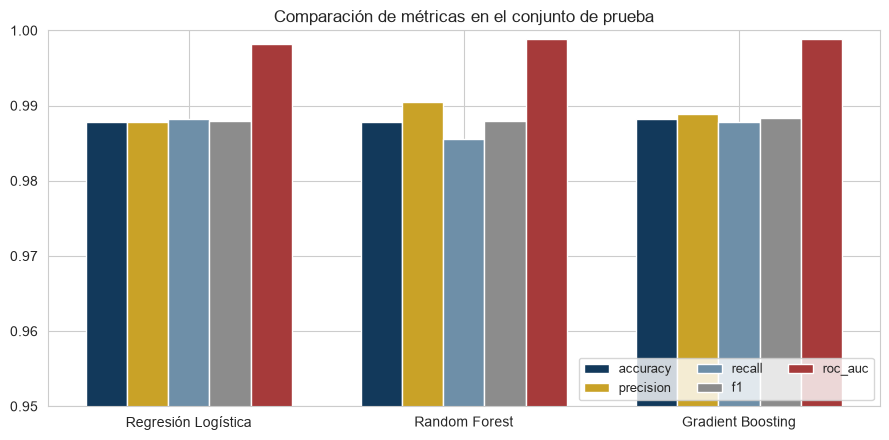

Mejor modelo (por ROC-AUC): Gradient Boosting


In [15]:
metrics_to_plot = ['accuracy_test', 'precision_test', 'recall_test', 'f1_test', 'roc_auc_test']
x = np.arange(len(results_df)); width = 0.15
colors = [NAVY, GOLD, '#6E8FA8', '#8C8C8C', '#A63A3A']
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + i*width, results_df[m], width, label=m.replace('_test', ''), color=colors[i])
ax.set_xticks(x + width*2); ax.set_xticklabels(results_df['modelo'])
ax.set_ylim(0.95, 1.0); ax.legend(loc='lower right', ncol=3, fontsize=9)
ax.set_title('Comparación de métricas en el conjunto de prueba')
plt.tight_layout(); plt.show()

best_name = results_df.sort_values('roc_auc_test', ascending=False).iloc[0]['modelo']
print("Mejor modelo (por ROC-AUC):", best_name)

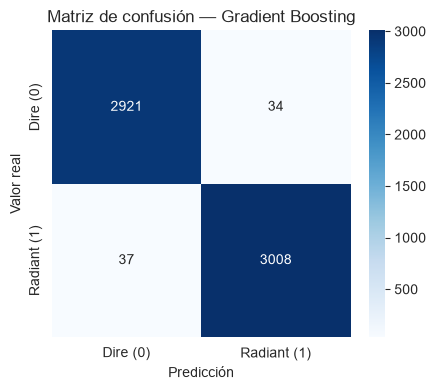

In [16]:
best_pipe = best_estimators[best_name]
y_pred_best = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Dire (0)', 'Radiant (1)'], yticklabels=['Dire (0)', 'Radiant (1)'])
ax.set_xlabel('Predicción'); ax.set_ylabel('Valor real')
ax.set_title(f'Matriz de confusión — {best_name}')
plt.tight_layout(); plt.show()

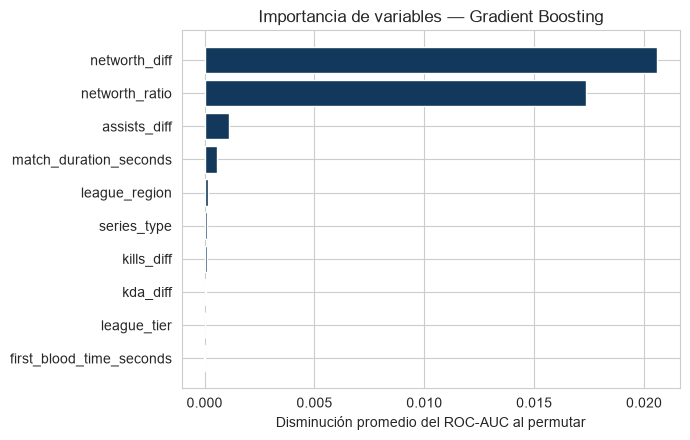

,variable,importancia
4,networth_diff,0.020605
5,networth_ratio,0.017349
3,assists_diff,0.001091
0,match_duration_seconds,0.000565
8,league_region,0.000159
9,series_type,0.000109
2,kills_diff,0.000089
6,kda_diff,0.000082
7,league_tier,0.000002
1,first_blood_time_seconds,-0.000009


In [17]:
# Importancia de variables del mejor modelo (permutation importance)
r = permutation_importance(best_pipe, X_test, y_test, n_repeats=5, random_state=42, scoring='roc_auc')
imp_df = pd.DataFrame({'variable': numeric_features + categorical_features,
                        'importancia': r.importances_mean}).sort_values('importancia', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(imp_df['variable'][::-1], imp_df['importancia'][::-1], color=NAVY)
ax.set_xlabel('Disminución promedio del ROC-AUC al permutar')
ax.set_title(f'Importancia de variables — {best_name}')
plt.tight_layout(); plt.show()
imp_df

## 9. Conclusiones

- El modelo de **Gradient Boosting** obtuvo el mejor desempeño (ROC-AUC ≈ 0.999, accuracy ≈ 98.8% en prueba),
  aunque los tres modelos obtuvieron resultados muy similares y altos.
- La variable más determinante fue **networth_diff** (diferencia de oro acumulado entre equipos), seguida de
  **networth_ratio** y **assists_diff**.
- La brecha mínima entre las métricas de entrenamiento y prueba indica bajo sobreajuste.
- **Trabajo a futuro:** incorporar variables disponibles antes del inicio de la partida (selección de héroes)
  y entrenar sobre el conjunto completo de datos con mayor capacidad de cómputo.